In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv(r"C:\Users\gaura\Desktop\Smart Support Ticket Classifier\data\X_train.csv")
y_train = pd.read_csv(r"C:\Users\gaura\Desktop\Smart Support Ticket Classifier\data\y_train.csv")
X_test  = pd.read_csv(r"C:\Users\gaura\Desktop\Smart Support Ticket Classifier\data\X_test.csv")
y_test  = pd.read_csv(r"C:\Users\gaura\Desktop\Smart Support Ticket Classifier\data\y_test.csv")

In [3]:
X_train.head()

,id,text
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...
2,584,[TICKET ID] - A Support Ticket was forwarded t...
3,1393,[TICKET ID] - A Support Ticket was forwarded t...
4,8636,LVS not respondingLVS will not except my passw...


In [4]:
y_train.head()

,id,category_truth
0,1919,Fileservice
1,1584,Fileservice
2,584,Support general
3,1393,Support general
4,8636,Fileservice


In [5]:
y_train.category_truth.value_counts()

category_truth
Fileservice          546
Support general      541
Software             164
O365                 127
Active Directory      84
Computer-Services     65
EOL                   45
Name: count, dtype: int64

In [6]:
X_train.shape

(1572, 2)

In [7]:
X_test.shape

(657, 2)

In [8]:
# merge for easy analysis
train = X_train.copy()
train['label'] = y_train['category_truth']

# text length distribution
train['text_len'] = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()

print(train.groupby('label')[['text_len', 'word_count']].mean().round(1))

                   text_len  word_count
label                                  
Active Directory      113.4        16.4
Computer-Services      60.5         9.2
EOL                   407.6        56.4
Fileservice           123.4        16.7
O365                   86.0        14.1
Software               75.4        11.5
Support general       153.2        20.6


C:\Users\gaura\AppData\Local\Temp\ipykernel_14080\2814368766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, y='label', order=order, palette='Blues_r')


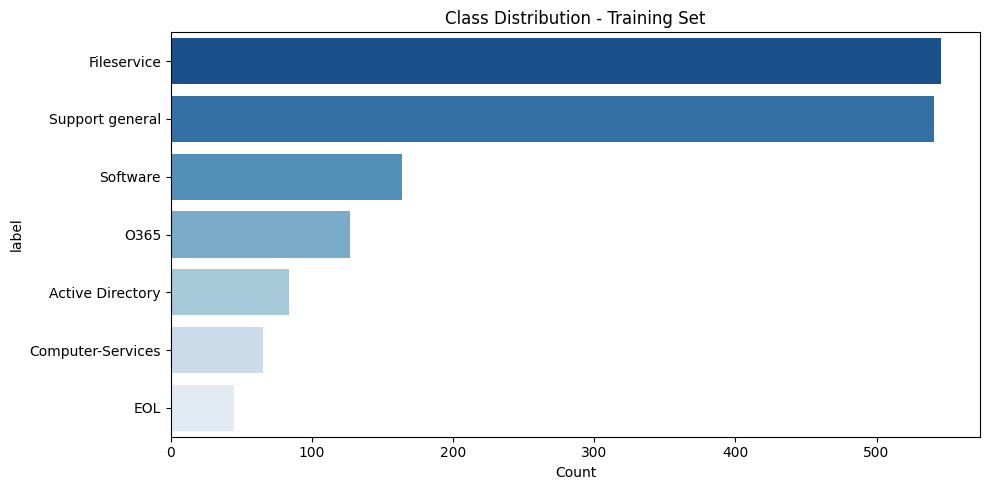

In [9]:
# class distribution plot
plt.figure(figsize=(10, 5))
order = train['label'].value_counts().index
sns.countplot(data=train, y='label', order=order, palette='Blues_r')
plt.title('Class Distribution - Training Set')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [10]:
# check for nulls and duplicates
print("Nulls:", train['text'].isna().sum())
print("Duplicates:", train['text'].duplicated().sum())
print("\nShortest tickets:")
print(train.nsmallest(3, 'word_count')[['text', 'label']])

Nulls: 0
Duplicates: 610

Shortest tickets:
                                                   text            label
120   Change[LOCATION]Entry[LOCATION]FirewallChange[...  Support general
1269                                           onedrive             O365
1362                                           [SERVER]         Software


In [11]:
print(train[train['text'].duplicated(keep=False)].groupby('label').size())

label
Active Directory      1
EOL                  44
Fileservice         360
O365                  2
Software             46
Support general     210
dtype: int64


In [12]:
# find cross-class duplicates (same text, different labels)
dup_texts = train[train['text'].duplicated(keep=False)][['text', 'label']]
cross_class = dup_texts.groupby('text')['label'].nunique()
print("Texts with multiple different labels:", (cross_class > 1).sum())

# look at a sample of the EOL duplicates
eol_dups = train[train['label'] == 'EOL']['text'].value_counts().head(3)
print("\nTop repeated EOL tickets:")
print(eol_dups)

Texts with multiple different labels: 1

Top repeated EOL tickets:
text
The following system must be set to End Of Life in Nexthink and checked for[LOCATION]reservations:  [SERVER]  -Automated ticket creation-Please remove the system from Nexthink according to the[LOCATION]process and please verify if any[LOCATION]reservations exist. If yes. please remove reservations and note down the corresponding IP(s) and inform [COMPANY] network team to remove firewall rules if there are any.    44
The following system must be set to End Of Life in Nexthink:  [SERVER]  -Automated ticket creation-The following system must be set to End Of Life in Nexthink:  [SERVER]                                                                                                                                                                                                                                                         1
Name: count, dtype: int64


In [13]:
# drop duplicates, keep first occurrence
train_clean = train.drop_duplicates(subset='text', keep='first')
print(train_clean['label'].value_counts())
print(f"\nWent from {len(train)} to {len(train_clean)} samples")

label
Support general      351
Fileservice          206
Software             129
O365                 126
Active Directory      83
Computer-Services     65
EOL                    2
Name: count, dtype: int64

Went from 1572 to 962 samples


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# use clean deduplicated data
train_clean = train.drop_duplicates(subset='text', keep='first')

# drop EOL - only 2 samples
train_clean = train_clean[train_clean['label'] != 'EOL']

X_tr = train_clean['text']
y_tr = train_clean['label']

# also drop EOL from test
test = X_test.copy()
test['label'] = y_test['category_truth']
test = test[test['label'] != 'EOL']

X_te = test['text']
y_te = test['label']

# build pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

print(classification_report(y_te, y_pred))

                   precision    recall  f1-score   support

 Active Directory       0.56      0.47      0.51        49
Computer-Services       0.76      0.63      0.69        41
      Fileservice       1.00      0.90      0.95       138
             O365       0.55      0.84      0.67        92
         Software       0.54      0.57      0.55        58
  Support general       0.82      0.75      0.78       221

         accuracy                           0.75       599
        macro avg       0.71      0.69      0.69       599
     weighted avg       0.77      0.75      0.75       599



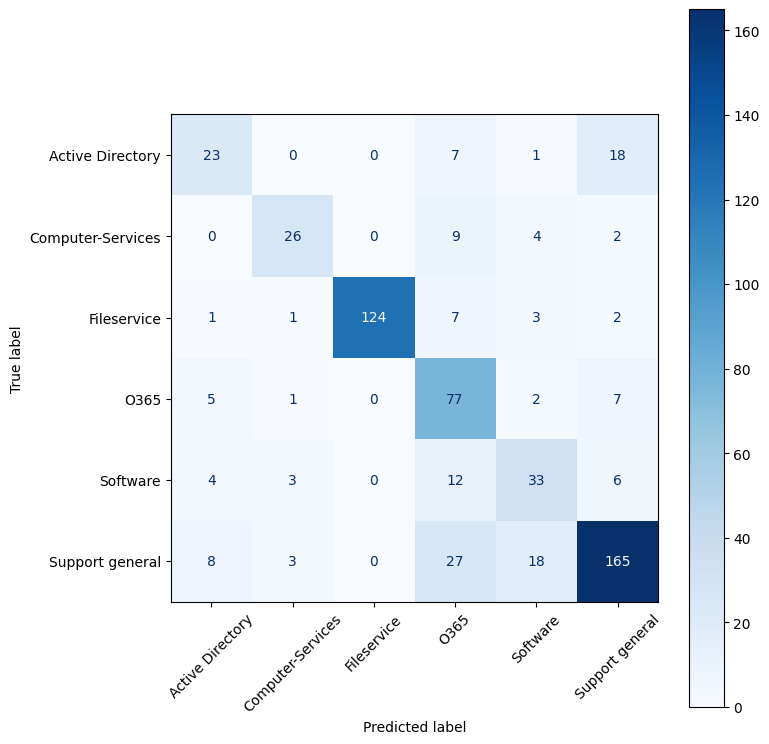

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_te, y_pred, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=pipe.classes_)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.tight_layout()
plt.show()

In [16]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

model_st = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Encoding train...")
X_tr_emb = model_st.encode(X_tr.tolist(), show_progress_bar=True)
print("Encoding test...")
X_te_emb = model_st.encode(X_te.tolist(), show_progress_bar=True)

clf_emb = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_emb.fit(X_tr_emb, y_tr)
y_pred_emb = clf_emb.predict(X_te_emb)

print(classification_report(y_te, y_pred_emb))

c:\Users\gaura\Desktop\Smart Support Ticket Classifier\nlpvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2904.49it/s]


Encoding train...


Batches: 100%|██████████| 30/30 [00:07<00:00,  4.28it/s]


Encoding test...


Batches: 100%|██████████| 19/19 [00:05<00:00,  3.45it/s]


                   precision    recall  f1-score   support

 Active Directory       0.46      0.53      0.49        49
Computer-Services       0.89      0.83      0.86        41
      Fileservice       0.92      0.95      0.93       138
             O365       0.70      0.76      0.73        92
         Software       0.64      0.62      0.63        58
  Support general       0.84      0.78      0.81       221

         accuracy                           0.78       599
        macro avg       0.74      0.75      0.74       599
     weighted avg       0.79      0.78      0.79       599



In [17]:
# save clean splits for use in future notebooks
train_clean.to_csv('data/train_clean.csv', index=False)
test_clean = test[test['label'] != 'EOL'].copy()
test_clean.to_csv('data/test_clean.csv', index=False)
print("Saved.")

Saved.


In [18]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# save TF-IDF pipeline
with open('models/tfidf_pipeline.pkl', 'wb') as f:
    pickle.dump(pipe, f)

# save embeddings classifier
with open('models/emb_classifier.pkl', 'wb') as f:
    pickle.dump(clf_emb, f)

# save the sentence transformer name so we know which one to load later
with open('models/model_info.txt', 'w') as f:
    f.write('paraphrase-multilingual-MiniLM-L12-v2')

print("Models saved.")

Models saved.
